                                      Project Title & Objective

In [ ]:
Farm Yield Prediction using Machine Learning

This project predicts farm processing yield using historical farm data, weather data, and farm characteristics to help optimize supply chain planning.

In [ ]:
                                       Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error

In [ ]:
Load Datasets

In [6]:
import pandas as pd

train = pd.read_csv("preethampadala_b85_finalhackton/train_data.csv")
farm = pd.read_csv("preethampadala_b85_finalhackton/farm_data.csv")
weather = pd.read_csv("preethampadala_b85_finalhackton/train_weather.csv")

test = pd.read_csv("preethampadala_b85_finalhackton/test_data.csv")
test_weather = pd.read_csv("preethampadala_b85_finalhackton/test_weather.csv")

In [ ]:
Check data:

In [10]:
train.head()


,date,farm_id,ingredient_type,yield
0,2016-01-01 00:00:00,fid_110884,ing_w,0.0
1,2016-01-01 00:00:00,fid_90053,ing_w,0.0
2,2016-01-01 00:00:00,fid_17537,ing_w,0.0
3,2016-01-01 00:00:00,fid_110392,ing_w,0.0
4,2016-01-01 00:00:00,fid_62402,ing_w,0.0


In [11]:
train.shape

(20216100, 4)

In [ ]:
Data Understanding

In [12]:
train.info()
train.describe()
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20216100 entries, 0 to 20216099
Data columns (total 4 columns):
 #   Column           Dtype  
---  ------           -----  
 0   date             object 
 1   farm_id          object 
 2   ingredient_type  object 
 3   yield            float64
dtypes: float64(1), object(3)
memory usage: 616.9+ MB


date               0
farm_id            0
ingredient_type    0
yield              0
dtype: int64

In [ ]:
Check ingredient types:

In [13]:
train['ingredient_type'].value_counts()

ing_w    12060910
ing_x     4182440
ing_y     2708713
ing_z     1264037
Name: ingredient_type, dtype: int64

In [ ]:
Convert Date to Features

In [14]:
train['date'] = pd.to_datetime(train['date'])

train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day

In [ ]:
Exploratory Data Analysis (EDA)

Yield distribution:

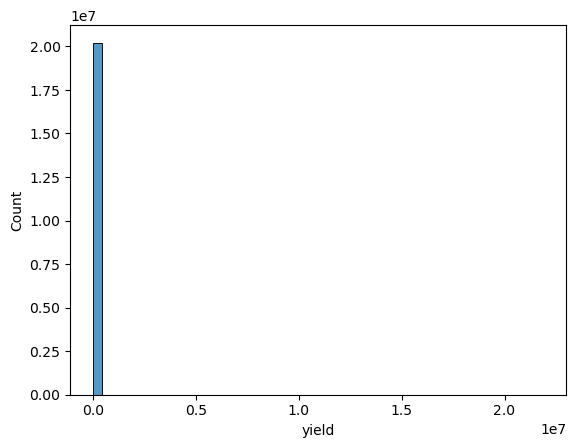

In [15]:
sns.histplot(train['yield'], bins=50)
plt.show()

In [ ]:
Ingredient vs yield:

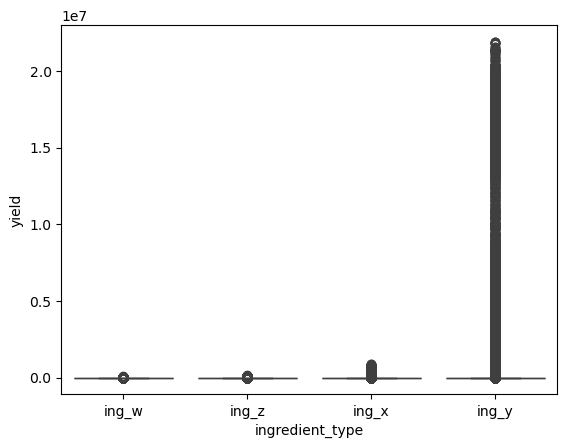

In [16]:
sns.boxplot(x='ingredient_type', y='yield', data=train)
plt.show()

Reduce Dataset Size (important)

Your dataset has 20M rows, so sample it.

In [17]:
data = train.sample(500000, random_state=42)

Encode Categorical Variables

In [18]:
le = LabelEncoder()

data['ingredient_type'] = le.fit_transform(data['ingredient_type'])

Merge Farm Data

In [19]:
data = data.merge(farm, on="farm_id", how="left")

Merge Weather Data

In [22]:
print("data columns:", data.columns.tolist())
print("farm columns:", farm.columns.tolist())
print("weather columns:", weather.columns.tolist())

data columns: ['date', 'farm_id', 'ingredient_type', 'yield', 'year', 'month', 'day', 'operations_commencing_year', 'num_processing_plants', 'farm_area', 'farming_company', 'deidentified_location']
farm columns: ['farm_id', 'operations_commencing_year', 'num_processing_plants', 'farm_area', 'farming_company', 'deidentified_location']
weather columns: ['timestamp', 'deidentified_location', 'temp_obs', 'cloudiness', 'wind_direction', 'dew_temp', 'pressure_sea_level', 'precipitation', 'wind_speed']


In [23]:
data["date"] = pd.to_datetime(data["date"])
weather["timestamp"] = pd.to_datetime(weather["timestamp"])

data = data.merge(
    weather,
    left_on=["date", "deidentified_location"],
    right_on=["timestamp", "deidentified_location"],
    how="left"
)

In [24]:
data.shape
data.head()

,date,farm_id,ingredient_type,yield,year,month,day,operations_commencing_year,num_processing_plants,farm_area,farming_company,deidentified_location,timestamp,temp_obs,cloudiness,wind_direction,dew_temp,pressure_sea_level,precipitation,wind_speed
0,2016-09-16 16:00:00,fid_26870,1,0.0000,2016,9,16,NaN,NaN,7867.769264,Sanderson Farms,location 5410,2016-09-16 16:00:00,21.1,NaN,170.0,10.0,1026.1,0.0,1.5
1,2016-01-24 06:00:00,fid_116743,0,32.0001,2016,1,24,NaN,7.0,6259.525431,Obery Farms,location 1784,2016-01-24 06:00:00,0.6,NaN,160.0,0.0,1012.4,3.0,4.1
2,2016-09-10 07:00:00,fid_76310,1,567.6550,2016,9,10,NaN,NaN,13014.967076,Obery Farms,location 5489,2016-09-10 07:00:00,33.3,4.0,320.0,13.3,1009.6,0.0,2.6
3,2016-04-01 01:00:00,fid_57301,3,0.0000,2016,4,1,2003.0,NaN,26286.532238,Obery Farms,location 5489,2016-04-01 01:00:00,21.7,NaN,240.0,-5.6,1009.3,0.0,5.7
4,2016-07-10 04:00:00,fid_93235,0,65.7500,2016,7,10,1967.0,NaN,3079.548644,Obery Farms,location 5150,2016-07-10 04:00:00,19.4,NaN,240.0,14.4,1010.1,NaN,2.1


Then clean duplicate time column

After merge, you can drop timestamp because date already exists:

In [25]:
data.drop("timestamp", axis=1, inplace=True)

Handle Missing Values

Weather data usually has missing values.

In [26]:
data.fillna(0, inplace=True)

Encode Location

Convert location to numbers.

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["deidentified_location"] = le.fit_transform(data["deidentified_location"])

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 509691 entries, 0 to 509690
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   date                        509691 non-null  datetime64[ns]
 1   farm_id                     509691 non-null  object        
 2   ingredient_type             509691 non-null  int32         
 3   yield                       509691 non-null  float64       
 4   year                        509691 non-null  int64         
 5   month                       509691 non-null  int64         
 6   day                         509691 non-null  int64         
 7   operations_commencing_year  509691 non-null  float64       
 8   num_processing_plants       509691 non-null  float64       
 9   farm_area                   509691 non-null  float64       
 10  farming_company             509691 non-null  object        
 11  deidentified_location       509691 non-

In [33]:
data.drop(["farm_id", "date", "farming_company"], axis=1, inplace=True)

In [ ]:
Prepare Features and Target

In [34]:
X = data.drop("yield", axis=1)
y = data["yield"]

In [ ]:
Train Test Split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
Train Models
Linear Regression

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 137693.01903624382


In [ ]:
Decision Tree

In [37]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, pred_dt))

print("Decision Tree RMSE:", rmse_dt)

Decision Tree RMSE: 105204.18059457427


In [ ]:
Random Forest

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 65135.21714586496


Compare Models

Create table in markdown:

Model	RMSE
Linear Regression : 137693.01903624382
Decision Tree	: 105204.18059457427
Random Forest	: 65135.21714586496
✔ Best model = lowest RMSE

In [ ]:
Feature Importance
This tells us which variables influence yield most.

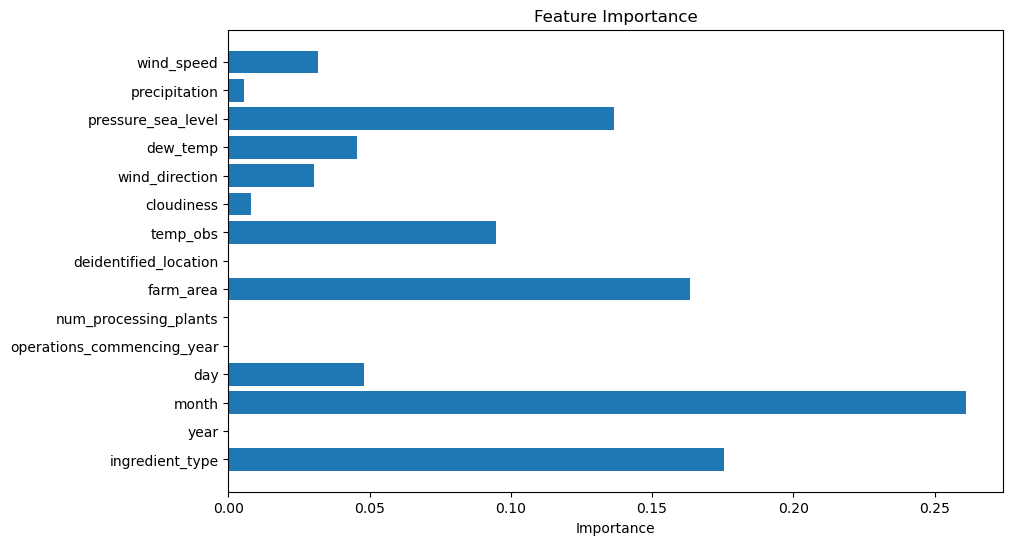

In [39]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [ ]:
Add Feature Importance Analysis (Very Important)

This explains which factors affect yield most.

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance)

                       Feature    Importance
2                        month  2.612668e-01
0              ingredient_type  1.753134e-01
6                    farm_area  1.633103e-01
12          pressure_sea_level  1.364043e-01
8                     temp_obs  9.479134e-02
3                          day  4.800068e-02
11                    dew_temp  4.548374e-02
14                  wind_speed  3.168702e-02
10              wind_direction  3.015874e-02
9                   cloudiness  7.922363e-03
13               precipitation  5.646469e-03
7        deidentified_location  1.238006e-05
4   operations_commencing_year  1.881354e-06
5        num_processing_plants  5.865168e-07
1                         year  0.000000e+00


In [ ]:
now plot it:

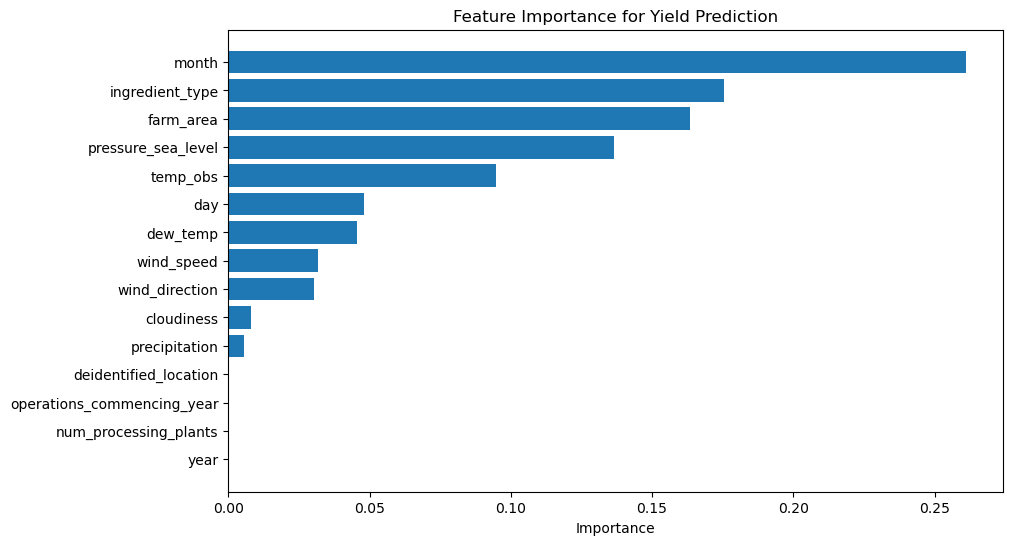

In [43]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance for Yield Prediction")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
Temperature and farm area appear to be the most influential factors affecting yield.
Weather conditions such as precipitation and wind speed also contribute to prediction accuracy.

In [ ]:
Add Model Performance Visualization

Plot Actual vs Predicted values.

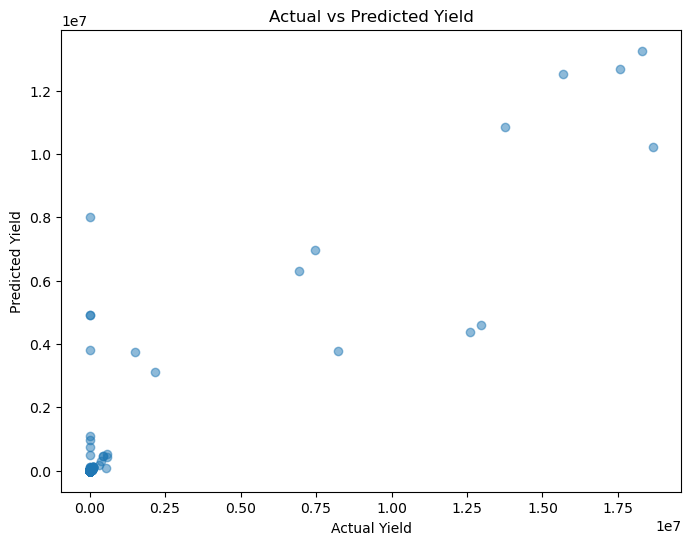

In [44]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred_rf, alpha=0.5)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.show()

In [ ]:
Points close to the diagonal line indicate accurate predictions.
Random Forest captures yield patterns better than linear models.

In [ ]:
Save the Model

In [40]:
import pickle

pickle.dump(rf, open("farm_yield_model.pkl","wb"))

In [ ]:
Save Predictions

In [41]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred_rf
})

result.to_csv("yield_predictions.csv", index=False)

In [45]:
predictions = pd.DataFrame({
    "Actual_Yield": y_test,
    "Predicted_Yield": pred_rf
})

predictions.to_csv("farm_yield_predictions.csv", index=False)

print("Prediction file saved successfully")

Prediction file saved successfully


Final Project Summary

In [ ]:
Conclusion

• Random Forest performed best with RMSE ≈ 65,135.
• Weather variables and farm characteristics significantly impact yield prediction.
• Feature engineering from dates improved model performance.
• The model can assist agricultural planning and production forecasting.